# Titanic dataset(classification)

Link: https://www.kaggle.com/datasets/yasserh/titanic-dataset/data 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from pandas.core.common import random_state
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
df = pd.read_csv('datasets/Titanic-Dataset.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Feature engineering

In [5]:
df = df.drop(columns=['PassengerId', 'Ticket', 'Cabin'])

In [6]:
df['Age'] = df['Age'].fillna(df.groupby('Pclass')['Age'].transform('median'))

In [7]:
df['Age'].isnull().sum()

np.int64(0)

In [8]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [9]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [10]:
print(f'All samples have title: {df["Title"].value_counts().sum() == len(df)}')

All samples have title: True


In [11]:
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

rare_titles = [
    'Lady',
    'Countess',
    'Capt',
    'Col',
    'Don',
    'Dr', 
    'Major',
    'Rev',
    'Sir',
    'Jonkheer',
    'Dona'
]
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [12]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    object 
 9   Title     891 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [15]:
df = pd.get_dummies(df, columns=['Embarked', 'Title'], prefix=['Emb', 'Title'], dtype=int)

In [16]:
df = df.drop(columns=['Name'], axis=1)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Survived      891 non-null    int64  
 1   Pclass        891 non-null    int64  
 2   Sex           891 non-null    int64  
 3   Age           891 non-null    float64
 4   SibSp         891 non-null    int64  
 5   Parch         891 non-null    int64  
 6   Fare          891 non-null    float64
 7   Emb_C         891 non-null    int64  
 8   Emb_Q         891 non-null    int64  
 9   Emb_S         891 non-null    int64  
 10  Title_Master  891 non-null    int64  
 11  Title_Miss    891 non-null    int64  
 12  Title_Mr      891 non-null    int64  
 13  Title_Mrs     891 non-null    int64  
 14  Title_Rare    891 non-null    int64  
dtypes: float64(2), int64(13)
memory usage: 104.5 KB


In [18]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Emb_C,Emb_Q,Emb_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,1,22.0,1,0,7.2500,0,0,1,0,0,1,0,0
1,1,1,0,38.0,1,0,71.2833,1,0,0,0,0,0,1,0
2,1,3,0,26.0,0,0,7.9250,0,0,1,0,1,0,0,0
3,1,1,0,35.0,1,0,53.1000,0,0,1,0,0,0,1,0
4,0,3,1,35.0,0,0,8.0500,0,0,1,0,0,1,0,0


## Sampling

In [19]:
RANDOM_STATE = 42

In [20]:
class DataSampler:
    def __init__(self, test_split=0.2, random_state=RANDOM_STATE):
        self.test_split = test_split
        self.random_state = random_state
        self.columns_to_standardize = ['Age', 'Fare']
        
    def random_sampling(self, df, sample_fraction):
        X_train, X_test, y_train, y_test = self.__split(df)
        
        X_train_sampled = X_train.sample(frac=sample_fraction, random_state=self.random_state)
        y_train_sampled = y_train.loc[X_train_sampled.index]
        
        X_train_sampled, X_test = self.__standardize(X_train_sampled, X_test)
        
        return X_train_sampled, X_test, y_train_sampled, y_test
        
    def __split(self, df):
        X = df.drop('Survived', axis=1)
        y = df['Survived']
        
        return train_test_split(
            X, 
            y, 
            test_size=self.test_split, 
            random_state=self.random_state
        )
    
    def __standardize(self, X_train_sampled, X_test):
        scaler = StandardScaler()
        
        X_train_sampled_scaled = X_train_sampled.copy()
        X_test_scaled = X_test.copy()
        
        X_train_sampled_scaled[self.columns_to_standardize] = scaler.fit_transform(X_train_sampled_scaled[self.columns_to_standardize])
        X_test_scaled[self.columns_to_standardize] = scaler.transform(X_test[self.columns_to_standardize])
        
        return X_train_sampled_scaled, X_test_scaled
        
    def bernoulli_sampling(self, df, sample_fraction):
        X_train, X_test, y_train, y_test = self.__split(df)
        rng = np.random.default_rng(self.random_state)
        
        mask = rng.binomial(1, sample_fraction, size=len(X_train)).astype(bool)
        
        X_train_sampled = X_train.loc[mask]
        y_train_sampled = y_train.loc[mask]
        
        X_train_sampled, X_test = self.__standardize(X_train_sampled, X_test)
        
        return X_train_sampled, X_test, y_train_sampled, y_test
    
    def systematic_sampling(self, df, sample_fraction):
        X_train, X_test, y_train, y_test = self.__split(df)
        
        k = max(1, int(1 / sample_fraction))
        rng = np.random.default_rng(self.random_state)
        start = rng.integers(0, k)
        
        X_train_sampled = X_train.iloc[start::k]
        y_train_sampled = y_train.loc[X_train_sampled.index]
        
        X_train_sampled, X_test = self.__standardize(X_train_sampled, X_test)
        
        return X_train_sampled, X_test, y_train_sampled, y_test

In [21]:
def fit_and_evaluate(X_train, y_train, X_test, y_test, random_state=RANDOM_STATE):
    model = LogisticRegression(max_iter=1000, random_state=random_state)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    
    return accuracy, precision, recall

In [26]:
sampler = DataSampler(test_split=0.2)
fractions = [i * 0.01 for i in range(1, 101)]

results = {
    'random': [],
    'bernoulli': [],
    'systematic': []
}

for fraction in tqdm.tqdm(fractions):
    X_train_rand, X_test_rand, y_train_rand, y_test_rand = sampler.random_sampling(df, fraction)
    accuracy_rand, precision_rand, recall_rand = fit_and_evaluate(X_train_rand, y_train_rand, X_test_rand, y_test_rand)
    results['random'].append({'accuracy': accuracy_rand, 'precision': precision_rand, 'recall': recall_rand})
    
    X_train_ber, X_test_ber, y_train_ber, y_test_ber = sampler.bernoulli_sampling(df, fraction)
    accuracy_ber, precision_ber, recall_ber = fit_and_evaluate(X_train_ber, y_train_ber, X_test_ber, y_test_ber)
    results['bernoulli'].append({'accuracy': accuracy_ber, 'precision': precision_ber, 'recall': recall_ber})
    
    X_train_sys, X_test_sys, y_train_sys, y_test_sys = sampler.systematic_sampling(df, fraction)
    accuracy_sys, precision_sys, recall_sys = fit_and_evaluate(X_train_sys, y_train_sys, X_test_sys, y_test_sys)
    results['systematic'].append({'accuracy': accuracy_sys, 'precision': precision_sys, 'recall': recall_sys})

100%|██████████| 100/100 [00:04<00:00, 24.46it/s]


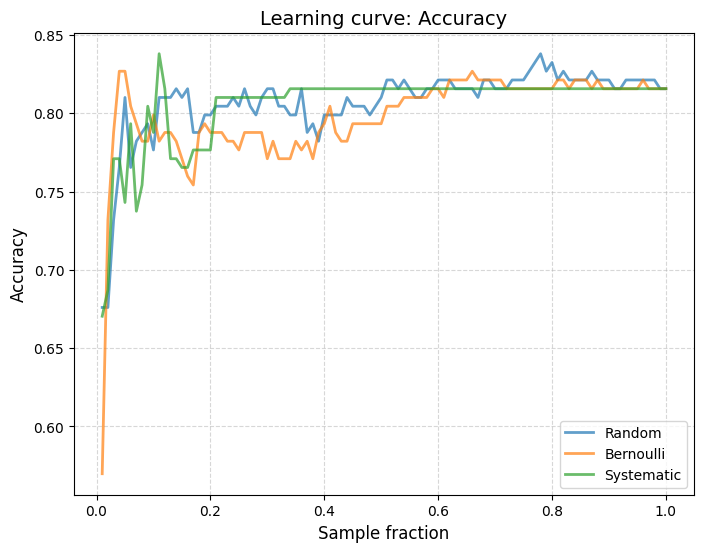

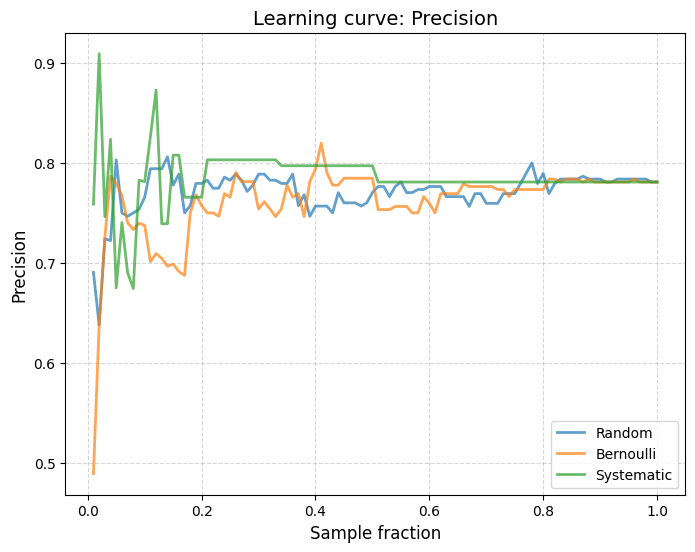

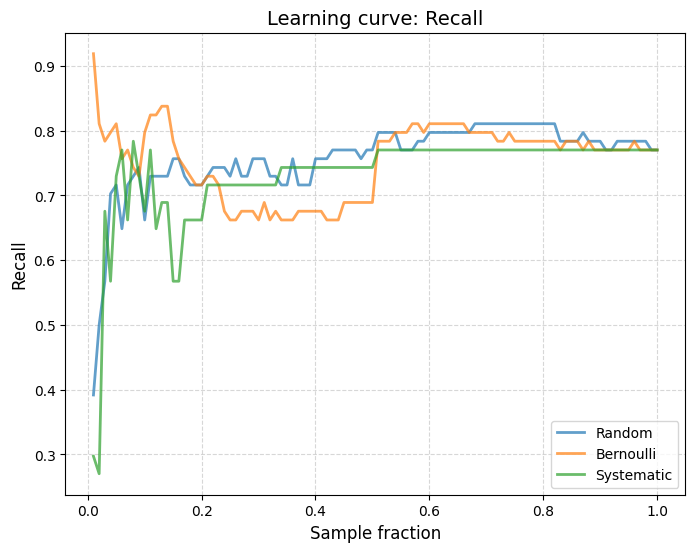

In [28]:
metrics = ['accuracy', 'precision', 'recall']
strategies = results.keys()

for metric in metrics:
    plt.figure(figsize=(8, 6))
    
    for strategy in strategies:
        y_values = [res[metric] for res in results[strategy]]
        
        plt.plot(
            fractions, 
            y_values, 
            label=strategy.capitalize(), 
            alpha=0.7,
            linewidth=2
        )
    
    plt.title(f'Learning curve: {metric.capitalize()}', fontsize=14)
    plt.xlabel('Sample fraction', fontsize=12)
    plt.ylabel(metric.capitalize(), fontsize=12)
        
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right', fontsize=10)
    
    plt.show()